In [1]:
# input
rep_info_file = "../../data/repId-numPro-numPredPro-numResi-numPredResi-numAnnoPro-isAnno.tsv"
# output
fig_file = "./fig/pred_consistency_size_5_kde.pdf"
fig2_file = "./fig/pred_consistency_size_5_bin.pdf"

In [2]:
import pandas as pd
df = pd.read_table(rep_info_file, header=None, names=["rep_id", "num_protein", "num_pred_protein", "num_residue", "num_pred_residue", "num_anno_pro", "is_anno"])

df = df[df['num_protein'] >= 5]
df['protein_pred_ratio'] = df['num_pred_protein'] / df['num_protein']
df['residue_pred_ratio'] = df['num_pred_residue'] / df['num_residue']
avg_pro_pred = df['num_pred_protein'].sum() / df['num_protein'].sum()
avg_resi_pred = df['num_pred_residue'].sum() / df['num_residue'].sum()
avg_pro_pred
avg_resi_pred

np.float64(0.8006069678566339)

np.float64(0.7418388834779571)

In [3]:
avg_seq_cluster_pro_pred = df['protein_pred_ratio'].sum() / len(df['protein_pred_ratio'])
avg_seq_cluster_res_pred = df['residue_pred_ratio'].sum() / len(df['residue_pred_ratio'])
avg_seq_cluster_pro_pred
avg_seq_cluster_res_pred

np.float64(0.8722031625221651)

np.float64(0.8207812182079034)

<Axes: xlabel='protein_pred_ratio', ylabel='Density'>

<Axes: xlabel='protein_pred_ratio', ylabel='Density'>

Text(0, 0.5, 'Density')

Text(0.5, 0, 'Consistency')

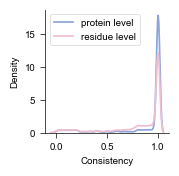

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

color_cycle = mpl.rcParams['axes.prop_cycle'].by_key()['color']
color1 = color_cycle[0]
color2 = color_cycle[1]

fig, ax = plt.subplots(figsize=(1.6, 1.6))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

sns.kdeplot(df['protein_pred_ratio'], lw=1.25)
sns.kdeplot(df['residue_pred_ratio'], lw=1.25)
## plt.axvline(x=avg_seq_cluster_pro_pred, linestyle='--', color=color1)
## plt.axvline(x=avg_seq_cluster_res_pred, linestyle='--', color=color2)

plt.ylabel("Density")
plt.xlabel("Consistency")
plt.legend(
    labels=[# 'total protein',
            'protein level',
            'residue level'],
    loc='upper left',
    bbox_to_anchor=(0,1)
)

fig.savefig(fig_file, bbox_inches="tight", transparent=True)

Text(0, 0.5, 'Percentage of sequence clusters')

Text(0.5, 0, 'Consistency range')

([<matplotlib.axis.XTick at 0x71563b241bd0>,
 [Text(0, 0, '(0, 0.2]'),
  Text(1, 0, '(0.2, 0.4]'),
  Text(2, 0, '(0.4, 0.6]'),
  Text(3, 0, '(0.6, 0.8]'),
  Text(4, 0, '(0.8, 1.0]')])

<BarContainer object of 5 artists>

<BarContainer object of 5 artists>

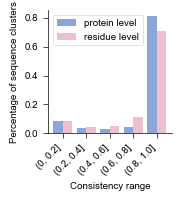

In [7]:
import numpy as np
bins = np.arange(0, 1.2, 0.2)

protein_ratio_cnt = pd.cut(
    df['protein_pred_ratio'],
    bins=bins,
    right=True,
    include_lowest=False
).value_counts().sort_index().to_list()

protein_ratio = [i / sum(protein_ratio_cnt) for i in protein_ratio_cnt]

residue_ratio_cnt = pd.cut(
    df['residue_pred_ratio'],
    bins=bins,
    right=True,
    include_lowest=False
).value_counts().sort_index().to_list()

residue_ratio = [i / sum(residue_ratio_cnt) for i in residue_ratio_cnt]

x = [
    "(0, 0.2]",
    "(0.2, 0.4]",
    "(0.4, 0.6]",
    "(0.6, 0.8]",
    "(0.8, 1.0]"
]

import matplotlib.pyplot as plt

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")



fig, ax = plt.subplots(figsize=(1.6, 1.6))
plt.ylabel("Percentage of sequence clusters")
plt.xlabel("Consistency range")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

coor_x = np.arange(len(x))


width = 0.4
plt.xticks(coor_x, labels=x, rotation=45, ha="right")
plt.bar(coor_x - width / 2, protein_ratio, width=width)
plt.bar(coor_x + width / 2, residue_ratio, width=width)
plt.legend(
    ['protein level', 'residue level'], 
    bbox_to_anchor=(0,1), 
    loc='upper left', 
)

fig.savefig(fig2_file, bbox_inches="tight", transparent=True)